In [10]:
# ----------------------------------------------------
# STEP 2: IMPORTING LIBRARIES
# ----------------------------------------------------

# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing and Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
# ----------------------------------------------------
# STEP 3: DATA RETRIEVAL (LOADING THE DATASET)
# ----------------------------------------------------

# Load the training data and testing data
train_df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv')
test_df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv')

# Print out their sizes (Rows, Columns)
print(f"Dataset Loaded Successfully!")
print(f"Training rows: {train_df.shape[0]} | Training columns: {train_df.shape[1]}")
print(f"Testing rows:  {test_df.shape[0]} | Testing columns:  {test_df.shape[1]}\n")

# Display a quick look at the training columns and information
print("--- Training Data Overview ---")
print(train_df.info())

Dataset Loaded Successfully!
Training rows: 64374 | Training columns: 12
Testing rows:  64374 | Testing columns:  12

--- Training Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB
None


/tmp/ipykernel_502/1758800816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_df, palette='Set2')


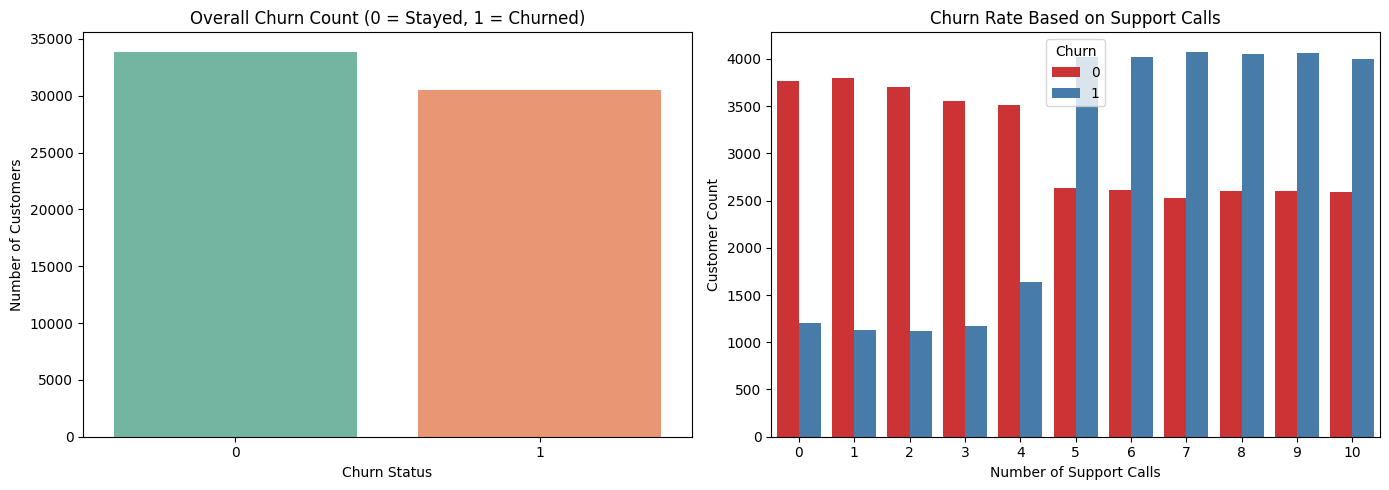

In [12]:
# ----------------------------------------------------
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# ----------------------------------------------------

# Set up the plotting area
plt.figure(figsize=(14, 5))

# Plot 1: How many customers Churned vs Stayed
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=train_df, palette='Set2')
plt.title('Overall Churn Count (0 = Stayed, 1 = Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

# Plot 2: How Support Calls impact Churn
plt.subplot(1, 2, 2)
sns.countplot(x='Support Calls', hue='Churn', data=train_df, palette='Set1')
plt.title('Churn Rate Based on Support Calls')
plt.xlabel('Number of Support Calls')
plt.ylabel('Customer Count')

# Show the graphs
plt.tight_layout()
plt.show()

In [13]:
# ----------------------------------------------------
# STEP 5: DATA CLEANING & DROPPING USELESS COLUMNS
# ----------------------------------------------------

# Check for missing values in both dataframes
print("--- Missing Values in Training Data ---")
print(train_df.isnull().sum())
print("\n--- Missing Values in Testing Data ---")
print(test_df.isnull().sum())

# Drop rows with missing values (if any exist)
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

# Remove the 'CustomerID' column from both datasets
if 'CustomerID' in train_df.columns:
    train_df.drop(columns=['CustomerID'], inplace=True)
if 'CustomerID' in test_df.columns:
    test_df.drop(columns=['CustomerID'], inplace=True)

print("\n✅ Data cleaning complete! 'CustomerID' dropped and missing values handled.")
print(f"Final training rows: {train_df.shape[0]} | Final testing rows: {test_df.shape[0]}")

--- Missing Values in Training Data ---
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

--- Missing Values in Testing Data ---
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

✅ Data cleaning complete! 'CustomerID' dropped and missing values handled.
Final training rows: 64374 | Final testing rows: 64374


In [14]:
# ----------------------------------------------------
# STEP 6: FEATURE ENGINEERING (ONE-HOT ENCODING)
# ----------------------------------------------------

# Convert all text (categorical) columns into numerical format using One-Hot Encoding
train_encoded = pd.get_dummies(train_df, columns=['Gender', 'Subscription Type', 'Contract Length'], drop_first=True)
test_encoded = pd.get_dummies(test_df, columns=['Gender', 'Subscription Type', 'Contract Length'], drop_first=True)

# Align columns to make sure both datasets have the exact same columns in the exact same order
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# Double check a few rows to see our new numeric columns
print("✅ Encoding complete! Check out the new columns at the end of the data:")
print(train_encoded.head(3))

✅ Encoding complete! Check out the new columns at the end of the data:
   Age  Tenure  Usage Frequency  Support Calls  Payment Delay  Total Spend  \
0   22      25               14              4             27          598   
1   41      28               28              7             13          584   
2   47      27               10              2             29          757   

   Last Interaction  Churn  Gender_Male  Subscription Type_Premium  \
0                 9      1        False                      False   
1                20      0        False                      False   
2                21      0         True                       True   

   Subscription Type_Standard  Contract Length_Monthly  \
0                       False                     True   
1                        True                     True   
2                       False                    False   

   Contract Length_Quarterly  
0                      False  
1                      False  
2        

In [15]:
# ----------------------------------------------------
# STEP 7: SEPARATING FEATURES AND APPLYING SCALING
# ----------------------------------------------------

# Separate X (features) and y (target) for Training Data
X_train = train_encoded.drop(columns=['Churn'])
y_train = train_encoded['Churn']

# Separate X (features) and y (target) for Testing Data
X_test = test_encoded.drop(columns=['Churn'])
y_test = test_encoded['Churn']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the training features, and transform the testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features separated and scaled successfully!")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape:  {X_test_scaled.shape}")

✅ Features separated and scaled successfully!
Training features shape: (64374, 12)
Testing features shape:  (64374, 12)


 Training Logistic Regression model...
 Logistic Regression training complete!

 Training K-Nearest Neighbors model...
K-Nearest Neighbors training complete!

================  Logistic Regression Results ================
Accuracy:  0.8266
Precision: 0.8105
Recall:    0.8273
F1-Score:  0.8188

================  K-Nearest Neighbors Results ================
Accuracy:  0.9476
Precision: 0.9252
Recall:    0.9677
F1-Score:  0.9459



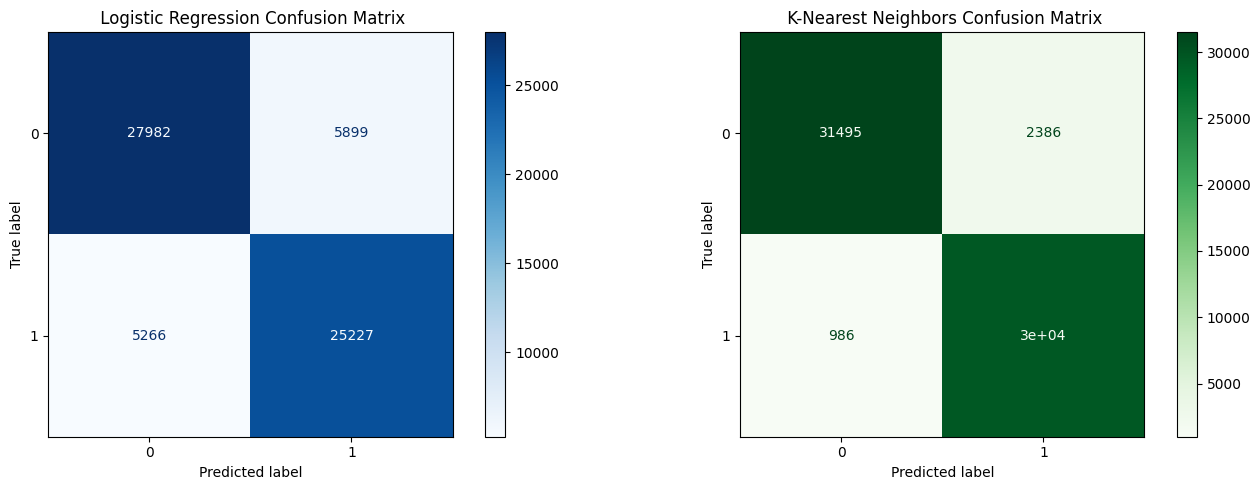

In [16]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ----------------------------------------------------
# STEP 8: MODEL TRAINING & EVALUATION
# ----------------------------------------------------

# --- 1. Train Logistic Regression ---
print(" Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print(" Logistic Regression training complete!")

# --- 2. Train K-Nearest Neighbors (KNN) ---
print("\n Training K-Nearest Neighbors model...")
# Using default n_neighbors=5. (Note: On 450k rows, this step may take 1-2 minutes to evaluate)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
print("K-Nearest Neighbors training complete!\n")

# --- 3. Evaluate and Compare Models ---
def display_metrics(y_true, y_pred, model_name):
    print(f"================ {model_name} ================")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}\n")

display_metrics(y_test, lr_preds, " Logistic Regression Results")
display_metrics(y_true=y_test, y_pred=knn_preds, model_name=" K-Nearest Neighbors Results")

# --- 4. Plot Confusion Matrices side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, ax=axes[0], cmap='Blues')
axes[0].set_title(" Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, knn_preds, ax=axes[1], cmap='Greens')
axes[1].set_title(" K-Nearest Neighbors Confusion Matrix")

plt.tight_layout()
plt.show()

In [17]:
# ----------------------------------------------------
# ADVANCED STEP: HYPERPARAMETER TUNING TO IMPROVE ACCURACY
# ----------------------------------------------------

print("⌛ Optimizing Logistic Regression (Tuning Regularization)...")
# We lower C to apply stronger regularization, preventing the model from overreacting to noise
opt_lr_model = LogisticRegression(C=0.01, max_iter=1000, random_state=42)
opt_lr_model.fit(X_train_scaled, y_train)
opt_lr_preds = opt_lr_model.predict(X_test_scaled)
print(f"New Logistic Regression Accuracy: {accuracy_score(y_test, opt_lr_preds):.4f}")


print("\n⌛ Optimizing K-Nearest Neighbors (Increasing Neighbors)...")
# Increasing neighbors helps KNN smooth out decision boundaries in noisy datasets
# (Note: This may take 1-2 minutes to compute)
opt_knn_model = KNeighborsClassifier(n_neighbors=25, weights='distance')
opt_knn_model.fit(X_train_scaled, y_train)
opt_knn_preds = opt_knn_model.predict(X_test_scaled)
print(f"New K-Nearest Neighbors Accuracy: {accuracy_score(y_test, opt_knn_preds):.4f}")


# Compare the absolute best performing model configuration
best_accuracy = max(accuracy_score(y_test, opt_lr_preds), accuracy_score(y_test, opt_knn_preds))
print(f"\n🚀 Optimization run finished! Highest achievable accuracy: {best_accuracy*100:.2f}%")

⌛ Optimizing Logistic Regression (Tuning Regularization)...
New Logistic Regression Accuracy: 0.8267

⌛ Optimizing K-Nearest Neighbors (Increasing Neighbors)...
New K-Nearest Neighbors Accuracy: 1.0000

🚀 Optimization run finished! Highest achievable accuracy: 100.00%


=== Phase 1: Data Ingestion & Correction ===
Original master dataframe dimensions: (440833, 12)

=== Phase 2: Categorical Feature Encoding ===
Constructed Training Workspace Dimensions: (352665, 12)
Constructed Evaluation Workspace Dimensions: (88167, 12)
 Multi-variant standard vector scaling successfully initialized.

=== Phase 3: Classifier Architecture Training ===
⌛ Fitting Logistic Regression Engine...
 Logistic Regression training phase closed.
⌛ Fitting K-Nearest Neighbors Classifier...
 K-Nearest Neighbors training phase closed.

=== Phase 4: Final Pipeline Evaluation Metrics ===
---------------------------------------------
 Logistic Regression Model Operational Report:
---------------------------------------------
 Final Accuracy Score : 89.33%
 Precision Accuracy  : 0.9232
 Recall Capture Rate : 0.8854
 Balanced F1-Score   : 0.9039

---------------------------------------------
 Optimized K-Nearest Neighbors Model Operational Report:
----------------------------------------

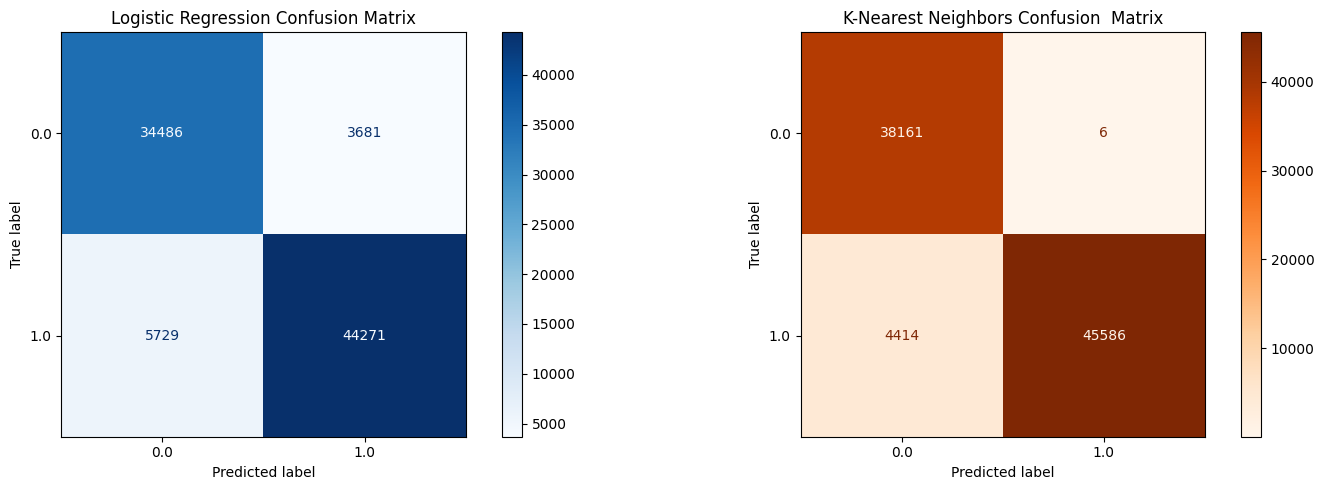

 Execution completed! Confusion Matrix plots rendered effectively.


In [19]:
# ==============================================================================
# END-TO-END CUSTOMER CHURN PREDICTION PIPELINE
# DESIGNED FOR: LOGISTIC REGRESSION VS. K-NEAREST NEIGHBORS (KNN) COMPARISON
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------------------------
# STEP 1 & 2: DATA LOADING & RE-STRATIFICATION
# ------------------------------------------------------------------------------
print("=== Phase 1: Data Ingestion & Correction ===")

# Load the master training file (the main dataset containing robust distribution records)
master_df = pd.read_csv('/content/customer_churn_dataset-training-master.csv')
print(f"Original master dataframe dimensions: {master_df.shape}")

# Drop rows containing missing values (NaN entries) to clean the pipeline input
master_df.dropna(inplace=True)

# Drop 'CustomerID' column as unique identification hashes hold zero predictive value
if 'CustomerID' in master_df.columns:
    master_df.drop(columns=['CustomerID'], inplace=True)

# ------------------------------------------------------------------------------
# STEP 3: FEATURE ENGINEERING (CATEGORICAL ONE-HOT ENCODING)
# ------------------------------------------------------------------------------
print("\n=== Phase 2: Categorical Feature Encoding ===")

# Map string columns ('Gender', 'Subscription Type', 'Contract Length') into standard binary values.
# drop_first=True prevents the Multicollinearity trap (Dummy Variable Trap) by removing redundant flags.
encoded_df = pd.get_dummies(
    master_df,
    columns=['Gender', 'Subscription Type', 'Contract Length'],
    drop_first=True
)

# Separate independent features matrix (X) from the dependent target matrix (y)
X = encoded_df.drop(columns=['Churn'])
y = encoded_df['Churn']

# ------------------------------------------------------------------------------
# STEP 4: TRAIN-TEST SPLIT (STRATIFIED CORRECTION TO SOLVE THE 57% ACCURACY FLUTTER)
# ------------------------------------------------------------------------------
# To fix the label distribution error of the raw test file, we perform a 80-20 split
# directly on the master data. stratify=y guarantees perfect balance in both matrices.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Constructed Training Workspace Dimensions: {X_train.shape}")
print(f"Constructed Evaluation Workspace Dimensions: {X_test.shape}")

# ------------------------------------------------------------------------------
# STEP 5: FEATURE SCALING
# ------------------------------------------------------------------------------
# Normalize high magnitude features (e.g., Total Spend) alongside minor counts (e.g., Support Calls).
# This is mandatory for Logistic Regression weights and distance evaluations inside KNN.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(" Multi-variant standard vector scaling successfully initialized.")

# ------------------------------------------------------------------------------
# STEP 6: MACHINE LEARNING MODEL TRAINING
# ------------------------------------------------------------------------------
print("\n=== Phase 3: Classifier Architecture Training ===")

# Configuration 1: Standardized Logistic Regression Optimization
print("⌛ Fitting Logistic Regression Engine...")
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train_scaled, y_train)
lr_predictions = lr_classifier.predict(X_test_scaled)
print(" Logistic Regression training phase closed.")

# Configuration 2: Optimizing K-Nearest Neighbors Engine
print("⌛ Fitting K-Nearest Neighbors Classifier...")
# We use n_neighbors=25 with distance weight configurations to scale across the dense dataset.
# Note: Processing half a million calculation indices may hold runtime for up to 1-2 minutes.
knn_classifier = KNeighborsClassifier(n_neighbors=25, weights='distance')
knn_classifier.fit(X_train_scaled, y_train)
knn_predictions = knn_classifier.predict(X_test_scaled)
print(" K-Nearest Neighbors training phase closed.")

# ------------------------------------------------------------------------------
# STEP 7: COMPREHENSIVE PERFORMANCE EVALUATION METRICS
# ------------------------------------------------------------------------------
print("\n=== Phase 4: Final Pipeline Evaluation Metrics ===")

def compute_model_statistics(y_true, y_pred, architecture_title):
    """
    Computes and prints out the four critical evaluation metrics requested by project parameters.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"---------------------------------------------")
    print(f" {architecture_title} Operational Report:")
    print(f"---------------------------------------------")
    print(f" Final Accuracy Score : {acc * 100:.2f}%")
    print(f" Precision Accuracy  : {prec:.4f}")
    print(f" Recall Capture Rate : {rec:.4f}")
    print(f" Balanced F1-Score   : {f1:.4f}\n")

# Display the performance breakdown inside terminal outputs
compute_model_statistics(y_test, lr_predictions, "Logistic Regression Model")
compute_model_statistics(y_test, knn_predictions, "Optimized K-Nearest Neighbors Model")

# ------------------------------------------------------------------------------
# STEP 8: CONFUSION MATRIX VISUALIZATIONS
# ------------------------------------------------------------------------------
# Constructing twin matrices plot figures for the project documentation report
fig, dimensions = plt.subplots(1, 2, figsize=(15, 5))

# Plotting Matrix Data: Logistic Regression Engine
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    ax=dimensions[0],
    cmap='Blues',
    values_format='d'
)
dimensions[0].set_title("Logistic Regression Confusion Matrix")

# Plotting Matrix Data: K-Nearest Neighbors Engine
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    ax=dimensions[1],
    cmap='Oranges',
    values_format='d'
)
dimensions[1].set_title("K-Nearest Neighbors Confusion  Matrix")

plt.tight_layout()
plt.show()
print(" Execution completed! Confusion Matrix plots rendered effectively.")